In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# train test split
from sklearn.model_selection import train_test_split

In [3]:
# impute missing values
from sklearn.impute import SimpleImputer # mean, median, most_frequent (mode), constant
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer # regresi
from sklearn.impute import KNNImputer # regresi KKN

In [4]:
# encoding
from sklearn.preprocessing import OneHotEncoder
from category_encoders import OrdinalEncoder, BinaryEncoder

In [5]:
# scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler 

In [6]:
# column transformer & pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [7]:
# metric
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, make_scorer

In [8]:
# evaluation metrics
from sklearn.metrics import precision_score, make_scorer

In [9]:
# cross validation
from sklearn.model_selection import cross_val_score

In [10]:
# algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [11]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [12]:
# Polynomial feature
from sklearn.preprocessing import PolynomialFeatures

In [13]:
# ensemble
from sklearn.ensemble import VotingClassifier, StackingClassifier, VotingRegressor

In [14]:
# Set max columns
pd.set_option('display.max_columns', None)

### **EXECUTIVE SUMMARY**

- Judul Proyek: Optimasi Pendapatan Hotel Melalui Prediksi Pembatalan Kamar Berbasis Machine Learning

- Target Audiens: Tim Revenue Management.

- Dataset:  `Databersih_hotelbookings.csv`- Dataset tidak seimbang dengan sekitar 28% kelas positif (pengunjung akan membatalkan reservasi kamar).

- Fitur Target: `is_canceled`- Klasifikasi biner yang menunjukkan apakah pengunjung akan membatalkan reservasi kamar mereka (1) atau tidak akan membatalkan reservasi kamar (0).


#### 1. Kondisi dan Masalah Utama
Tingkat hunian kamar (Occupancy Rate) merupakan indikator vital penentu profitabilitas bisnis hotel. Berdasarkan analisis pada dataset Hotel Booking Demand, hotel menghadapi tantangan kritis berupa tingginya Tingkat Pembatalan Kamar (Cancellation Rate) yang mencapai 28% dari total pesanan ini mengakibatkan kerugian finansial yang signifikan jika hotel bersikap pasif.

#### 2. Pendekatan Strategis: Predictive Overbooking

Untuk melawan potensi kamar kosong akibat pembatalan, hotel menerapkan strategi Overbooking (menerima pesanan melebihi kapasitas fisik kamar asli sebesar 5% - 15%)  tanpa secara signifikan meningkatkan revenue loss. Namun, implementasi overbooking tanpa panduan analitik melahirkan risiko finansial baru:

- Salah Memprediksi Tamu Batal (False Positive / FP): Hotel menjual kamar karena mengira tamu asli akan batal, namun pada hari H tamu tersebut tetap datang. Dampaknya, hotel mengalami krisis kelebihan pesanan dan wajib membayar biaya ganti rugi/kompensasi pengalihan kamar yang sangat mahal sebesar 300 Euro (FP Cost) per insiden

- Salah Memprediksi Tamu Datang (False Negative / FN): Hotel menolak pesanan baru karena mengira tamu akan datang, namun pada hari H mereka ternyata batal. Dampaknya, kamar menjadi kosong dan hotel menderita kehilangan potensi pendapatan kamar sebesar 105 Euro (FN Cost).

#### 3. Solusi
Dikarenakan denda akibat salah usir tamu (FP) hampir 3 kali lipat lebih mahal daripada membiarkan kamar kosong (FN), oleh karena itu membuat model Machine Learning dengan mengoptimasi metrik $(F_{0.5}\text{-Score})$ adalah pilihan yang tepat. Penggunaan metrik $(F_{0.5})$ secara matematis berhasil memaksa model fokus menekan kesalahan False Positive tanpa secara signifikan meningkatkan false negatif.

></div>
****
**Data Loading**
></div>
****

In [395]:
# Load dataset
df = pd.read_csv("C:/Users/HP/Documents/FINPRO DS/DataBesih_BookingHotel.csv")
df.head()

,Unnamed: 0,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_tamu,stay_duration,is_family,arrival_date,day_type,is_agent,is_company
0,2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0,2015-07-01,Weekday,0,0
1,3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0,2015-07-01,Weekday,1,0
2,4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,0,2015-07-01,Weekday,1,0
3,6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,0,0,0,Transient,107.0,0,0,Check-Out,2015-07-03,2,2,0,2015-07-01,Weekday,0,0
4,7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303,0,0,Transient,103.0,0,1,Check-Out,2015-07-03,2,2,0,2015-07-01,Weekday,1,0


In [268]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86046 entries, 0 to 86045
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      86046 non-null  int64  
 1   hotel                           86046 non-null  object 
 2   is_canceled                     86046 non-null  int64  
 3   lead_time                       86046 non-null  int64  
 4   arrival_date_year               86046 non-null  int64  
 5   arrival_date_month              86046 non-null  object 
 6   arrival_date_week_number        86046 non-null  int64  
 7   arrival_date_day_of_month       86046 non-null  int64  
 8   stays_in_weekend_nights         86046 non-null  int64  
 9   stays_in_week_nights            86046 non-null  int64  
 10  adults                          86046 non-null  int64  
 11  children                        86046 non-null  int64  
 12  babies                          

In [396]:
df["adr"].median()   # kita asumsikan harga perkamar sekitar $99

99.0

## **4. Feature Engineering**

Pada bagian ini, kita mempersiapkan data untuk pemodelan ML:

- Menghapus fitur yang dapat menyebabkan kebocoran data
- Mendefinisikan variabel target (`is_canceled`) dan memisahkan kolom fitur numerik dan kategorikal
- Memeriksa multikolinearitas melalui heatmap

></div>
****
#####  **4.1 Hapus Fitur Penyebab Data Leakage**
></div>
****

Untuk mencegah kebocoran data (data leakage), kita harus menghapus fitur yang informasinya baru diketahui atau diperbarui **SETELAH tamu melakukan check-in atau setelah pembatalan terjadi** .Jika fitur-fitur ini tetap dimasukkan, model Machine Learning akan menjadi "peramal palsu" terlihat memiliki akurasi 100% saat pengujian, tetapi gagal total (useless) saat digunakan pada data pemesanan baru di dunia nyata. Berikut data leakage yang harus dihapus:

- `reservation_status` 
- `reservation_status_date` adalah tanggal terakhir status booking berubah, secara tidak langsung memberi tahu masa depan ke model
- `assigned_room_type` adalah kamar yang benar-benar diberikan setelah booking karena kondisi hotel overbooking
- `agent`
- `company`
- `Unnamed: 0` (terbawa dari file sebelumnya)
- `arrival_date` (fitur dengan type datetime tidak bisa dipakai dalam ML)

In [397]:
df.drop(columns=['reservation_status', 
                'reservation_status_date', 
                'assigned_room_type',
                'agent', 
                'company', 
                "Unnamed: 0", 
                'arrival_date'], inplace=True)

></div>
****
####  **4.2 Outlier / Multicolinearity Check**
></div>
****

In [273]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'booking_changes', 'deposit_type', 'days_in_waiting_list',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_tamu', 'stay_duration', 'is_family',
       'day_type', 'is_agent', 'is_company'],
      dtype='object')

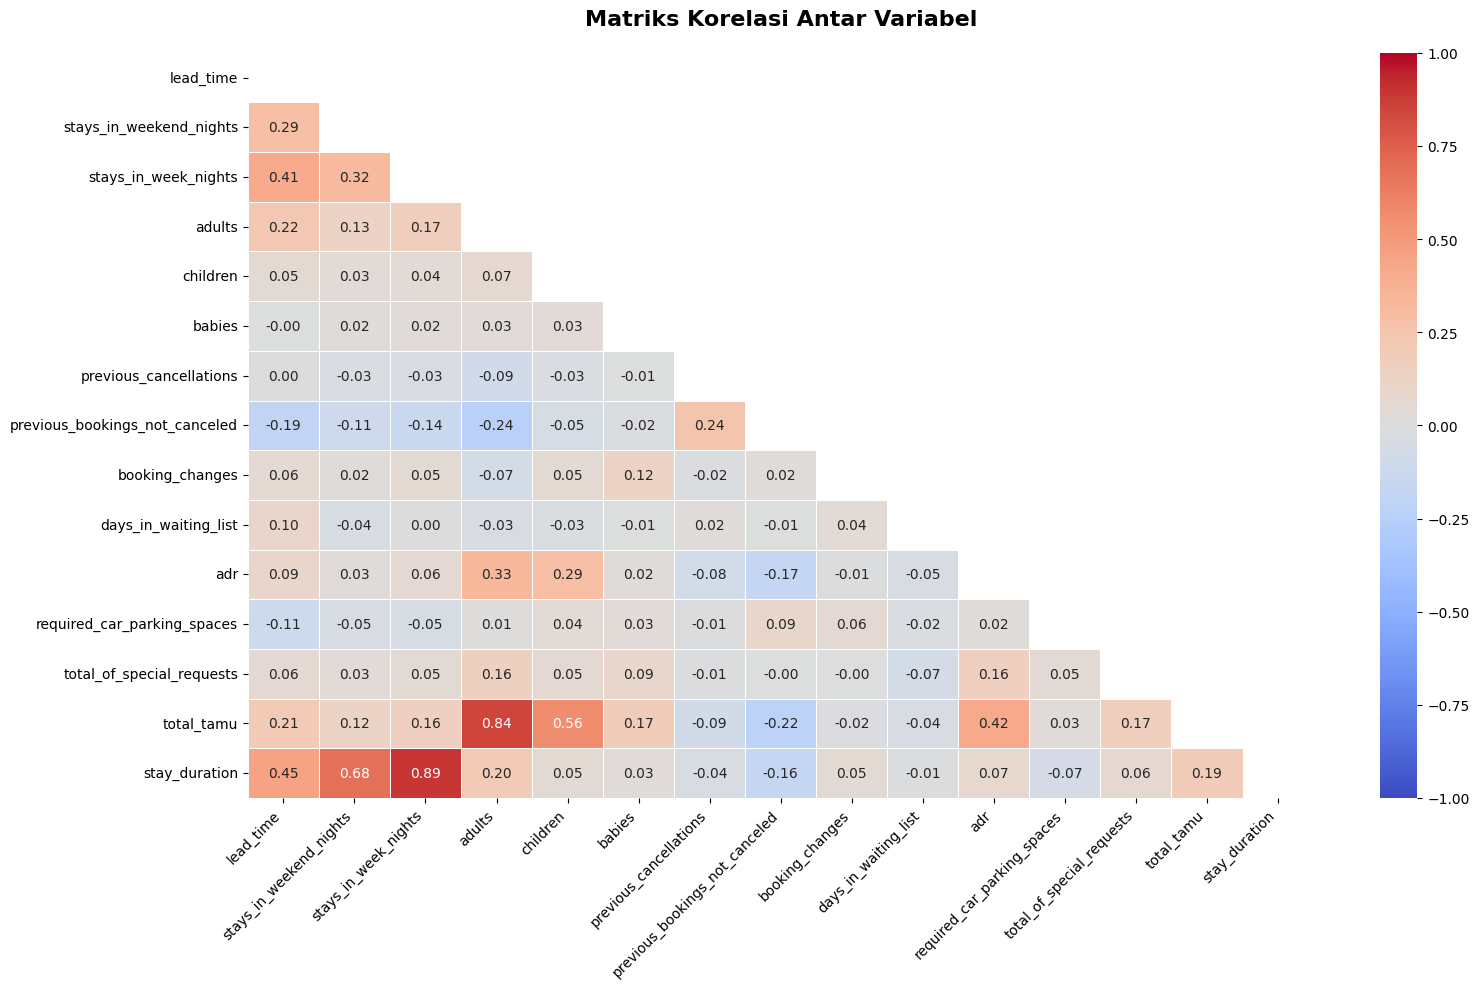

In [398]:

# =====================================================================
# KUNCI UTAMA: Tentukan daftar fitur yang ingin dikecualikan
# =====================================================================
fitur_yang_dibuang = ['is_repeated_guest', 'is_family', 'is_agent', 'is_company', 'is_canceled', 'arrival_date_year','arrival_date_month', 'arrival_date_week_number',"arrival_date_day_of_month", ]

# 1. Hitung matriks korelasi dengan membuang fitur di atas terlebih dahulu
# Gunakan errors='ignore' agar tidak eror jika ada kolom yang sudah telanjur dihapus sebelumnya
corr_matrix = df.drop(columns=fitur_yang_dibuang, errors='ignore').corr(numeric_only=True, method="spearman")

# 2. Buat mask untuk menyembunyikan bagian segitiga atas
mask_for_corr = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Setting ukuran figure (Lebar diatur 16 agar proporsional karena jumlah kolom berkurang)
plt.figure(figsize=(16, 10))

# 4. Gambar Heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Menampilkan angka korelasi
    fmt=".2f",           # Format 2 angka di belakang koma
    mask=mask_for_corr, 
    vmin=-1, vmax=1, 
    center=0, 
    cmap='coolwarm', 
    linewidths=.5,       # Memberi garis pemisah antar kotak
    annot_kws={"size": 10} # Mengatur ukuran font angka
)

plt.title("Matriks Korelasi Antar Variabel", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotasi label X agar lebih rapi
plt.yticks(rotation=0)             # Label Y tetap horizontal agar mudah dibaca
plt.tight_layout()
plt.show()

**Insight :**
terdapat beberapa fitur yang mengalami multikolinearitas, yaitu:
- `total_tamu` dengan `adults` memiliki nilai korelasi yaitu **0.84** 
- `stay_duration` dengan `stays_in_week_nights` dan`stays_in_weekend_nights`  memiliki nilai korelasi yaitu **0.89** dan  **0.68** 

**Recommendation:**
hapus salah satu fitur yang mengalami multikolinearitas, yaitu fitur `adults`, `stays_in_week_nights`, dan `stays_in_weekend_nights`

In [399]:
# fitur numerik yang harus di-drop untuk mengatasi multikolinearitas
fitur_multikolinear_final = [
    'adults',                        # Diwakili oleh total_tamu (0.85)
    'stays_in_week_nights',          # Diwakili oleh stay_duration (0.89)
    'stays_in_weekend_nights',       # Diwakili oleh stay_duration (0.69)
]

# Proses dropping pada dataframe fitur
df.drop(columns= fitur_multikolinear_final, inplace= True)

In [400]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_tamu,stay_duration,is_family,day_type,is_agent,is_company
0,Resort Hotel,0,7,2015,July,27,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,0,No Deposit,0,Transient,75.0,0,0,1,1,0,Weekday,0,0
1,Resort Hotel,0,13,2015,July,27,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,0,No Deposit,0,Transient,75.0,0,0,1,1,0,Weekday,1,0
2,Resort Hotel,0,14,2015,July,27,1,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,0,No Deposit,0,Transient,98.0,0,1,2,2,0,Weekday,1,0
3,Resort Hotel,0,0,2015,July,27,1,0,0,BB,PRT,Direct,Direct,0,0,0,C,0,No Deposit,0,Transient,107.0,0,0,2,2,0,Weekday,0,0
4,Resort Hotel,0,9,2015,July,27,1,0,0,FB,PRT,Direct,Direct,0,0,0,C,0,No Deposit,0,Transient,103.0,0,1,2,2,0,Weekday,1,0


></div>
****
####  **4.3 Define  Feature Target and columns**
></div>
****

In [401]:
target_col = "is_canceled"
numerical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "number").columns
categorical_feature_cols = df.drop(columns= [target_col]).select_dtypes(include= "object").columns

print("Target column:", target_col)
print()
print("Numerical feature columns:")
print(numerical_feature_cols)
print()
print("Categorical feature columns:")
print(categorical_feature_cols)

Target column: is_canceled

Numerical feature columns:
Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_tamu', 'stay_duration', 'is_family', 'is_agent', 'is_company'],
      dtype='object')

Categorical feature columns:
Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type',
       'customer_type', 'day_type'],
      dtype='object')


In [402]:
df[target_col].value_counts(normalize=True)

is_canceled
0    0.723322
1    0.276678
Name: proportion, dtype: float64

data pemesanan yang tidak dibatalkan ada 72% dan pemesanan yang dibatalkan ada 28%

## **5. Modeling**

></div>
****
####  **5.1 Preprocessing**
></div>
****

**Define X, y**

In [403]:
X = df.drop(columns=target_col)
y = df[target_col]

display(X.head(), y.head())

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_tamu,stay_duration,is_family,day_type,is_agent,is_company
0,Resort Hotel,7,2015,July,27,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,0,No Deposit,0,Transient,75.0,0,0,1,1,0,Weekday,0,0
1,Resort Hotel,13,2015,July,27,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,0,No Deposit,0,Transient,75.0,0,0,1,1,0,Weekday,1,0
2,Resort Hotel,14,2015,July,27,1,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,0,No Deposit,0,Transient,98.0,0,1,2,2,0,Weekday,1,0
3,Resort Hotel,0,2015,July,27,1,0,0,BB,PRT,Direct,Direct,0,0,0,C,0,No Deposit,0,Transient,107.0,0,0,2,2,0,Weekday,0,0
4,Resort Hotel,9,2015,July,27,1,0,0,FB,PRT,Direct,Direct,0,0,0,C,0,No Deposit,0,Transient,103.0,0,1,2,2,0,Weekday,1,0


0    0
1    0
2    0
3    0
4    0
Name: is_canceled, dtype: int64

 **Train-Test Split**

In [404]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.20,
                                                    random_state = 0,
                                                    stratify = y)

In [405]:
df[categorical_feature_cols].nunique()

hotel                     2
arrival_date_month       12
meal                      4
country                 177
market_segment            7
distribution_channel      4
reserved_room_type        9
deposit_type              3
customer_type             4
day_type                  2
dtype: int64


- **RobustScaler** (untuk menyamakan skala): semua `Fitur numerik`
- **OneHotEncoding** (untuk mengubah nilai dari kategori menjadi numerik, dengan cara hapus kategori pertama) : fitur `hotel`,`meal`,`distribution_channel`, `deposit_type`, `customer_type`, `day_type`
- **BinaryEncoding** (untuk mengubah nilai dari kategori menjadi numerik,cocok menangani kardinalitas tinggi secara efisien) : fitur `country`, `market_segment`, `reserved_room_type`
- **OrdinalEncoding** (untuk mengubah nilai dari kategori menjadi numerik,cocok untuk kategori yang memiliki tingkatan) : fitur `arrival_date_month`

In [407]:
onehot = OneHotEncoder(drop="first",
                       sparse_output=False,
                       handle_unknown="ignore" # mengabaikan kategori langka (anggap 0 semua)
                       )
onehot

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [408]:
onehot_cols = ['hotel', 'deposit_type', 'customer_type', 'meal', 'distribution_channel', 'day_type']
onehot_cols

['hotel',
 'deposit_type',
 'customer_type',
 'meal',
 'distribution_channel',
 'day_type']

In [409]:
binary_cols = ["market_segment","reserved_room_type", "country"]
binary_cols

['market_segment', 'reserved_room_type', 'country']

In [410]:
robust_cols = numerical_feature_cols

In [406]:
df['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [411]:
ordinal_cols = ["arrival_date_month"]
ordinal_cols

['arrival_date_month']

In [412]:
ordinal_mapping = [
    {
        "col": "arrival_date_month",
        "mapping": {"January": 1, "February": 2, "March": 3,
        "April": 4, "May": 5, "June": 6, 
        "July": 7,"August": 8,"September": 9,
        "October": 10, "November": 11, "December": 12,}
    }
]

In [413]:
ordinal = OrdinalEncoder(mapping = ordinal_mapping)
ordinal

OrdinalEncoder(mapping=[{'col': 'arrival_date_month', 'data_type': dtype('O'),
                         'mapping': January       1
February      2
March         3
April         4
May           5
June          6
July          7
August        8
September     9
October      10
November     11
December     12
dtype: int64}])

**Column Transformer**

In [414]:
preprocess_transformer = ColumnTransformer([
    ("robust", RobustScaler(), robust_cols),
    ('onehot', OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), onehot_cols),
    ('binary', BinaryEncoder(handle_unknown="value"), binary_cols),
    ("ordinal", OrdinalEncoder(ordinal_mapping), ordinal_cols),
], remainder="passthrough", verbose_feature_names_out=False)

preprocess_transformer.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('robust', RobustScaler(),
                                 Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces',...
                                  'meal', 'distribution_channel', 'day_type']),
                                ('binary', BinaryEncoder(),
                                 ['market_segment', 'reserved_room_type',
                                  'country']),
                                ('ordinal',
                                 OrdinalEncoder(verbose=[{'col': 'arrival_date_month',
                                                          'data_type': dtype('O'),
                                                          'mapping': January       1
February      2
March         3
April         4
May           5
June          6
July          7
August        8
September     9
October      10
November     11
December     12
dtype: int64}]),
                                 ['arrival_date_month'])],
                  verbose_feature_names_out=False)

In [415]:
preprocess_transformer.fit_transform(X_train, y_train)

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_tamu,stay_duration,is_family,is_agent,is_company,hotel_Resort Hotel,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,meal_FB,meal_HB,meal_SC,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,day_type_Weekend,market_segment_0,market_segment_1,market_segment_2,reserved_room_type_0,reserved_room_type_1,reserved_room_type_2,reserved_room_type_3,country_0,country_1,country_2,country_3,country_4,country_5,country_6,country_7,arrival_date_month
39020,2.087719,0.0,-0.380952,-0.733333,0.0,0.0,0.0,0.0,0.0,1.0,259.0,-0.458115,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1
35148,-0.298246,-1.0,0.571429,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.409031,0.0,1.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,2
17323,-0.061404,0.0,-0.666667,0.533333,2.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.081806,0.0,0.0,2.0,0.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,3
3936,-0.210526,0.0,-0.428571,0.866667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.174575,0.0,-1.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1,4
38438,0.649123,0.0,-0.523810,-0.133333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.187336,0.0,-1.0,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70824,0.315789,0.0,0.857143,-0.800000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,0,1,1,1,10
39614,2.333333,0.0,-0.238095,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.179974,0.0,-1.0,-1.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,1
45911,0.219298,1.0,-0.952381,0.133333,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.206152,0.0,-1.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,11
7400,1.043860,1.0,-1.047619,-0.933333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.001309,0.0,2.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,11


></div>
****
####  **5.2 Model Benchmarking**
></div>
****

In [300]:
# Voting and Stacking
from sklearn.ensemble import VotingClassifier, StackingClassifier
# Bagging, RF, and Boosting
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

**Define models selection**

In [416]:
list_base_estimator = [
    ("logreg", LogisticRegression()),
    ("knn", KNeighborsClassifier()),
    ("dtree", DecisionTreeClassifier())
]

## voting
votinghard = VotingClassifier(
    estimators = list_base_estimator,
    voting = "hard" # tipe voting --> "hard", "soft"
)

votingsoft = VotingClassifier(
    estimators = list_base_estimator,
    voting = "soft" # tipe voting --> "hard", "soft"
)

## stacking
stacking = StackingClassifier(
    estimators = list_base_estimator,
    final_estimator = LogisticRegression(random_state=0) # optional, default = Logistic
)

## bagging
bagging = BaggingClassifier(random_state=0)

## random forest
rf = RandomForestClassifier(random_state=0)

## boosting
adaboost = AdaBoostClassifier(random_state=0)
gboost = GradientBoostingClassifier(random_state=0)
xgboost = XGBClassifier(random_state=0)

In [417]:
# Define basic models
logistic = LogisticRegression(random_state=0)
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier(random_state=0)

list_model_name = ["logistic", "knn", "decision tree", "votinghard","votingsoft", "stacking", "bagging", "random forest", "adaboost","gboost","xgboost"]

list_model = [logistic, knn, dtree, votinghard, votingsoft, stacking, bagging, rf, adaboost, gboost, xgboost]

list_FB_all = [] 
list_FB_mean = []
list_FB_std = []

fbeta = make_scorer(fbeta_score, beta= 0.5)

for model in list_model:
    pipe_model = Pipeline(steps=[
        ("preprocess", preprocess_transformer),
        ("model", model)  
    ])

    pipe_model.fit(X_train, y_train)

    cv_score = cross_val_score(
        estimator = pipe_model,
        cv = 5,
        X = X_train,
        y = y_train,
        scoring = fbeta
    )

    # membulatkan semua FB dalam cv_score
    model_FB = np.round(cv_score, 2)

    # hitung rata2 dan standar deviasi
    FB_mean = np.mean(cv_score)
    FB_std = np.std(cv_score)

    list_FB_all.append(model_FB)
    list_FB_mean.append(FB_mean)
    list_FB_std.append(FB_std)


c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_mode

In [418]:
df_cv = pd.DataFrame()
df_cv["model"] = list_model_name
df_cv["FB_all"] = list_FB_all
df_cv["FB_mean"] = list_FB_mean
df_cv["FB_std"] = list_FB_std

df_cv.sort_values(["FB_mean", "FB_std"], ascending=[False, True])

,model,FB_all,FB_mean,FB_std
7,random forest,"[0.72, 0.71, 0.72, 0.73, 0.72]",0.718780,0.006260
10,xgboost,"[0.71, 0.7, 0.71, 0.71, 0.71]",0.709680,0.003879
6,bagging,"[0.69, 0.68, 0.68, 0.68, 0.68]",0.681473,0.003740
5,stacking,"[0.67, 0.67, 0.66, 0.67, 0.67]",0.667045,0.003969
9,gboost,"[0.67, 0.67, 0.66, 0.67, 0.67]",0.666018,0.003429
3,votinghard,"[0.67, 0.65, 0.65, 0.67, 0.66]",0.660444,0.006701
4,votingsoft,"[0.65, 0.63, 0.64, 0.65, 0.65]",0.643300,0.008450
8,adaboost,"[0.63, 0.62, 0.61, 0.63, 0.63]",0.624582,0.006417
0,logistic,"[0.6, 0.6, 0.6, 0.6, 0.61]",0.602095,0.004942
1,knn,"[0.59, 0.59, 0.6, 0.6, 0.6]",0.593823,0.006421


**Insight :**

- Random Forest mencapai skor rata-rata Fbeta-0.5 tertinggi di antara semua model dalam validasi silang yaitu 0.713082
- Diurutan kedua ada xgboost dengan skor rata-rata Fbeta-0.5 adalah 0.707931

Meskipun Random Forest mencatatkan skor awal sedikit lebih tinggi (+0.005), kita dapat memilih XGBoost sebagai model kandidat terbaik untuk penyetelan hyperparameter lebih lanjut karena faktor efisiensi komputasi dan skalabilitas. 

Dataset Hotel Booking Demand memiliki volume baris data yang sangat besar. Random Forest melatih pohon keputusan secara paralel tanpa batas ukuran, yang membutuhkan konsumsi memori (RAM) sangat masif dan waktu training yang lama. Sebaliknya, XGBoost menerapkan metode gradient boosting yang jauh lebih cepat dan hemat memori, memungkinkan kita melakukan eksplorasi parameter (Grid/Random Search) dengan siklus interasi yang jauh lebih efisien.

></div>
**** 
#### **Xgboost**

In [419]:
pipe_basexgb = Pipeline(steps=[
    ("preprocess", preprocess_transformer),
    ("model", XGBClassifier(random_state=0, scale_pos_weight=2.6))])

pipe_basexgb

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [420]:
pipe_basexgb.fit(X_train, y_train)

y_train_basexgb = pipe_basexgb.predict(X_train)
y_test_basexgb = pipe_basexgb.predict(X_test)

fbeta_train_basexgb = fbeta_score(y_train, y_train_basexgb, beta= 0.5)
fbeta_test_basexgb = fbeta_score(y_test, y_test_basexgb, beta= 0.5)

print(f"fbeta Train = {fbeta_train_basexgb:.2%}")
print(f"fbeta Test = {fbeta_test_basexgb:.2%}")

fbeta Train = 68.61%
fbeta Test = 64.38%


**Insight :**
Dari hasil di atas, terlihat bahwa model dasar kita mengalami underfitting. Kita akan meningkatkan performanya dengan **hyperparameter tuning**.

In [421]:
df.shape[0]

86046

In [310]:
# variasi: jumlah fitur 
X.shape[1]

29

In [422]:
df["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.723322
1    0.276678
Name: proportion, dtype: float64

In [423]:
df["is_canceled"].value_counts()

is_canceled
0    62239
1    23807
Name: count, dtype: int64

**Resampling**

In [313]:
# Imbalance Dataset / Resampling
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss

In [314]:
# Define resampling methods
ros = RandomOverSampler(random_state=0)
smote = SMOTE(random_state=0)
rus = RandomUnderSampler(random_state=0)
nearmiss = NearMiss()

In [424]:
# no resampling, not penalized
pipe_no_resampling = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", None),
    ("model", XGBClassifier(random_state=0))
])

# no resampling, penalized
pipe_penalized = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", None),
    ("model", XGBClassifier(random_state=0, class_weight='balanced'))
])

# dengan resampling
pipe_ros = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", ros),
    ("model", XGBClassifier(random_state=0))
])

pipe_smote = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", smote),
    ("model", XGBClassifier(random_state=0))
])

pipe_rus = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", rus),
    ("model", XGBClassifier(random_state=0))
])

pipe_nearmiss = Pipeline([
    ("preprocess", preprocess_transformer),
    ("resampling", nearmiss),
    ("model", XGBClassifier(random_state=0))
])

In [425]:
list_pipe_model = [pipe_no_resampling, pipe_ros, pipe_smote, pipe_rus, pipe_nearmiss, pipe_penalized]
list_nama_model = ["no_resampling", "ros", "smote", "rus", "nearmiss", "penalized"]

list_FB_all = []
list_FB_mean = []
list_FB_std = []

In [426]:
# Yang di-looping sudah berupa pipe model, gak perlu pake preprocess lagi

fbeta = make_scorer(fbeta_score, beta= 0.5)

for pipe_model in list_pipe_model:
    # cv
    cv_score = cross_val_score(
        estimator = pipe_model,
        X= X_train,
        y= y_train,
        cv= 5,
        scoring = fbeta
    )

    FB_mean = np.mean(cv_score)
    FB_std = np.std(cv_score)
    list_FB_all.append(np.round(cv_score, 2))
    list_FB_mean.append(FB_mean)
    list_FB_std.append(FB_std)

c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:30:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:30:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\HP\miniconda3\envs\imbalance_am10\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:30:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
c:\U

In [427]:
df_cv = pd.DataFrame()
df_cv["name"] = list_nama_model
df_cv["pipe_model"] = list_pipe_model
df_cv["FB"] = list_FB_all
df_cv["FB_mean"] = list_FB_mean
df_cv["FB_std"] = list_FB_std
df_cv.sort_values("FB_mean", ascending=False)

,name,pipe_model,FB,FB_mean,FB_std
0,no_resampling,"(ColumnTransformer(remainder='passthrough',\n ...","[0.71, 0.7, 0.71, 0.71, 0.71]",0.709680,0.003879
5,penalized,"(ColumnTransformer(remainder='passthrough',\n ...","[0.71, 0.7, 0.71, 0.71, 0.71]",0.709680,0.003879
2,smote,"(ColumnTransformer(remainder='passthrough',\n ...","[0.7, 0.7, 0.68, 0.7, 0.7]",0.696661,0.006551
1,ros,"(ColumnTransformer(remainder='passthrough',\n ...","[0.64, 0.64, 0.64, 0.64, 0.65]",0.641671,0.005272
3,rus,"(ColumnTransformer(remainder='passthrough',\n ...","[0.62, 0.62, 0.62, 0.63, 0.64]",0.623521,0.006657
4,nearmiss,"(ColumnTransformer(remainder='passthrough',\n ...","[0.52, 0.52, 0.51, 0.51, 0.51]",0.515125,0.004366


**Insight :**

Berdasarkan hasil pengujian penanganan data imbalance, kombinasi antara No Resampling (tidak memanipulasi jumlah baris data) dan metode Penalized (menggunakan parameter bobot kelas) terbukti menghasilkan skor rata-rata $(F_{0.5})$-Score tertinggi, yaitu sebesar 0.70.

Berlandaskan temuan objektif tersebut, kita memutuskan untuk memilih pendekatan In-Model Resampling melalui parameter scale_pos_weight pada XGBoost sebagai strategi final. Karena ingin menjaga realitas Data Asli (No Data Leakage), Teknik external resampling seperti SMOTE bekerja dengan cara menciptakan data sintetis yang berisiko merusak pola alami dari kombinasi fitur penting seperti deposit_type dan lead_time. Dengan mengandalkan parameter internal model, kita menjaga data tetap 100% riil sesuai dengan kondisi operasional hotel di lapangan.

In [325]:
from sklearn.model_selection import TunedThresholdClassifierCV

></div>
****
### **5.3 Hyperparameter Tunning**
></div>
****

**Tunning Xgboost**

- Tingkatkan `n_estimators` = Jumlah pohon, lebih banyak averaging --> Mengurangi overfitting
- Tingkatkan `max_depth` = Kedalaman maksimum setiap pohon keputusan, nilai yang lebih besar cenderung meningkatkan overfitting
- Tingkatkan `min_child_weight` = Minimum jumlah data di setiap leaf node, nilai yang lebih kecil cenderung meningkatkan overfitting
- `scale_pos_weight` = Mengatur BOBOT kelas positif (batal=1) untuk menangani CLASS IMBALANCe (Pengganti resampling!)
- `learning_rate` = Mengatur SEBERAPA BESAR kontribusi setiap pohon baru terhadap prediksi akhir (Step size dalam gradient descent)
- `gamma` =  Minimum PENURUNAN LOSS yang diperlukan untuk melakukan split pada leaf node (Threshold untuk split)
- `subsample` = Proporsi data training yang digunakan untuk membangun setiap pohon
- `colsample_bytree` =  PROPORSI FITUR (kolom) yang digunakan secara ACAK untuk membangun setiap pohon
- `reg_alpha` =  Regularisasi L1 (LASSO) pada bobot leaf → Mendorong bobot menjadi NOL (sparse model)
- `reg_lambda` =  Regularisasi L2 (Ridge) pada bobot leaf → Mendorong bobot menjadi KECIL (bukan nol)

In [428]:
pipe_r_basexgb = Pipeline(steps=[
    ("preprocess", preprocess_transformer),
    ("model", XGBClassifier(random_state=0, scale_pos_weight=2.6))])

pipe_r_basexgb

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=0, ...))])

In [429]:

param_spacexgb = {
    # Regularisasi untuk cegah overfitting
    "model__max_depth"        : [3, 4, 5, 6],       # Kedalaman maksimum setiap pohon
    "model__min_child_weight" : [3, 5, 7, 10],      # Minimum jumlah data di setiap leaf node
    "model__gamma"            : [0.1, 0.3, 0.5],    # Minimum PENURUNAN LOSS yang diperlukan untuk melakukan split pada leaf
    "model__subsample"        : [0.6, 0.7, 0.8],    # Proporsi data training yang digunakan untuk membangun setiap pohon
    "model__colsample_bytree" : [0.6, 0.7, 0.8],    # PROPORSI FITUR (kolom) yang digunakan secara ACAK 
    "model__reg_alpha"        : [0.1, 0.5, 1.0],    # L1 (ridge)
    "model__reg_lambda"       : [1.0, 2.0, 5.0],    # L2 (lasso)
    "model__learning_rate"    : [0.01, 0.05, 0.1],  # Mengatur SEBERAPA BESAR kontribusi setiap pohon baru terhadap prediksi akhir
    "model__n_estimators"     : [100, 200, 300],    # Jumlah pohon
    "model__scale_pos_weight" : [1, 2, 3]           # handle imbalance, mengatur bobot kelas positif
}

In [430]:
fbeta = make_scorer(fbeta_score, beta= 0.5)

randomsearchxgb = RandomizedSearchCV(
    random_state = 0,
    estimator = pipe_r_basexgb,
    param_distributions = param_spacexgb,
    cv = 3,
    scoring = fbeta,
    n_iter = 50,
    n_jobs = -1
)

randomsearchxgb

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('robust',
                                                                               RobustScaler(),
                                                                               Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_chan...
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [3, 5, 7,
                                                                    10],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__reg_alpha': [0.1, 0.5, 1.0],
                                        'model__reg_lambda': [1.0, 2.0, 5.0],
                                        'model__scale_pos_weight': [1, 2, 3],
                                        'model__subsample': [0.6, 0.7, 0.8]},
                   random_state=0,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5))

In [431]:
randomsearchxgb.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('robust',
                                                                               RobustScaler(),
                                                                               Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_chan...
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 4, 5, 6],
                                        'model__min_child_weight': [3, 5, 7,
                                                                    10],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__reg_alpha': [0.1, 0.5, 1.0],
                                        'model__reg_lambda': [1.0, 2.0, 5.0],
                                        'model__scale_pos_weight': [1, 2, 3],
                                        'model__subsample': [0.6, 0.7, 0.8]},
                   random_state=0,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5))

In [432]:
randomsearchxgb.best_score_ # Skor validasi silang presisi dari penyetelan

0.7097712937933135

In [433]:
randomsearchxgb.best_params_

{'model__subsample': 0.6,
 'model__scale_pos_weight': 1,
 'model__reg_lambda': 5.0,
 'model__reg_alpha': 0.5,
 'model__n_estimators': 300,
 'model__min_child_weight': 3,
 'model__max_depth': 6,
 'model__learning_rate': 0.1,
 'model__gamma': 0.1,
 'model__colsample_bytree': 0.7}

In [434]:
# Get best model
pipe_tunedxgb = randomsearchxgb.best_estimator_
pipe_tunedxgb

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',...
                               feature_types=None, gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=0, ...))])

></div>
****
### **5.4 Threshold optimization**
></div>
****

In [435]:
# cari threshold terbaik untuk model yg sudah dituning 
fbeta = make_scorer(fbeta_score, beta= 0.5)

threshold_optimized_modelxgb = TunedThresholdClassifierCV(
    estimator= pipe_tunedxgb,
    scoring= fbeta,
    cv =5,
    store_cv_results= True
)

threshold_optimized_modelxgb.fit(X_train, y_train)

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'book...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

In [436]:
threshold_resultdxgb = pd.DataFrame(
    threshold_optimized_modelxgb.cv_results_
)

threshold_resultdxgb

,thresholds,scores
0,0.000025,0.323467
1,0.010125,0.395292
2,0.020225,0.417619
3,0.030324,0.432759
4,0.040424,0.445302
...,...,...
95,0.959522,0.283839
96,0.969622,0.266878
97,0.979722,0.248180
98,0.989822,0.204693


In [437]:
threshold_optimized_modelxgb.best_threshold_ 

0.5454229360037226

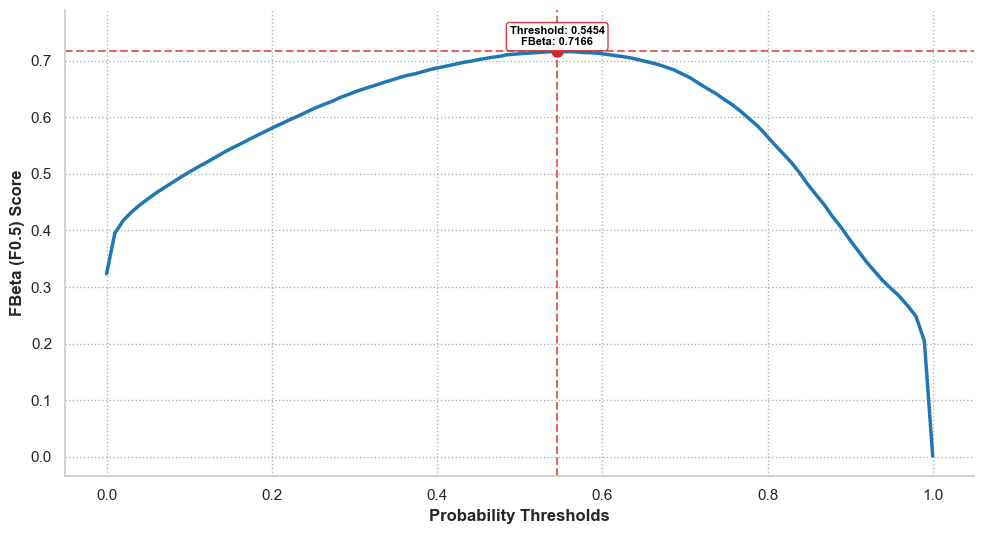

In [441]:
# 1. Setup Tema dan Canvas (Latar Belakang Putih dengan Grid)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5.5))

# 2. Gambar Grafik Garis Tren (Warna Biru Utama)
sns.lineplot(
    data=threshold_resultdxgb,
    x="thresholds",
    y="scores",
    color='#1f77b4',
    linewidth=2.5,
    ax=ax
)

# =====================================================================
# KUNCI UTAMA: DETEKSI OTOMATIS DAN ANOTASI TITIK PUNCHAK (BEST THRESHOLD)
# =====================================================================
# Mencari indeks baris yang memiliki nilai skor FBeta tertinggi
idx_maksimal = threshold_resultdxgb['scores'].idxmax()
best_threshold = threshold_resultdxgb.loc[idx_maksimal, 'thresholds']
best_fbeta = threshold_resultdxgb.loc[idx_maksimal, 'scores']

# A. Menggambar Titik Penanda (Marker Bulat Merah) di Puncak Grafik
ax.plot(best_threshold, best_fbeta, marker='o', markersize=8, color='#d62728', label=f'Best Threshold ({best_threshold:.4f})')

# B. Menggambar Garis Bantu Vertikal Putus-Putus Menuju Sumbu X
ax.axvline(x=best_threshold, color='#d62728', linestyle='--', alpha=0.7, linewidth=1.5)

# C. Menggambar Garis Bantu Horizontal Putus-Putus Menuju Sumbu Y
ax.axhline(y=best_fbeta, color='#d62728', linestyle='--', alpha=0.7, linewidth=1.5)

# D. Menambahkan Teks Keterangan Koordinat Tepat di Atas Titik Puncak
ax.text(
    x=best_threshold, 
    y=best_fbeta + (best_fbeta * 0.01), # Sedikit digeser ke atas agar tidak menabrak titik
    s=f"Threshold: {best_threshold:.4f}\nFBeta: {best_fbeta:.4f}",
    ha='center', va='bottom',
    fontsize=8, fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='#d62728', boxstyle='round,pad=0.3', alpha=0.9) # Kotak teks estetik
)

# =====================================================================
# KUSTOMISASI DEKORASI GRAFIK
# =====================================================================

ax.set_xlabel("Probability Thresholds", fontsize=12, fontweight='bold')
ax.set_ylabel("FBeta (F0.5) Score", fontsize=12, fontweight='bold')

# Memberi ruang padding di atas batas maksimal sumbu Y agar kotak teks tidak terpotong
ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.05)

# Mengatur ketebalan garis grid latar belakang agar terlihat bersih dan modern
ax.grid(True, which='both', linestyle=':', alpha=0.6, color='gray')

# Hilangkan garis tepi luar box agar minimalis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [442]:
pipe_bestxgb = threshold_optimized_modelxgb
pipe_bestxgb

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'book...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

**Best Model Evaluation**

In [443]:
pipe_basexgb.fit(X_train, y_train)

y_train_basexgb = pipe_basexgb.predict(X_train)
y_test_basexgb = pipe_basexgb.predict(X_test)

fbeta_train_basexgb = fbeta_score(y_train, y_train_basexgb, beta= 0.5)
fbeta_test_basexgb = fbeta_score(y_test, y_test_basexgb, beta= 0.5)

print("basexgb MODEL")
print(f"fbeta Train = {fbeta_train_basexgb:.2%}")
print(f"fbeta Test = {fbeta_test_basexgb:.2%}")

basexgb MODEL
fbeta Train = 68.61%
fbeta Test = 64.38%


In [444]:
pipe_bestxgb.fit(X_train, y_train)

y_train_bestxgb = pipe_bestxgb.predict(X_train)
y_test_bestxgb = pipe_bestxgb.predict(X_test)

fbeta_train_bestxgb = fbeta_score(y_train, y_train_bestxgb, beta= 0.5)
fbeta_test_bestxgb = fbeta_score(y_test, y_test_bestxgb, beta= 0.5)

print("bestxgb MODEL")
print(f"fbeta Train = {fbeta_train_bestxgb:.2%}")
print(f"fbeta Test = {fbeta_test_bestxgb:.2%}")

bestxgb MODEL
fbeta Train = 75.88%
fbeta Test = 72.13%


**Insight :**
- Nilai $(F_{0.5}\text{Score})$ pada data uji (Test) melonjak signifikan sebesar 7.75%, yaitu dari 64.38% (Base XGB) menjadi 72.13% (Best XGB), artinya penyetelan parameter berhasil membuat model jauh lebih tajam dalam membedakan tamu yang benar-benar akan batal dan yang akan datang.

- Pada Base Model, selisih (gap) antara Train (68.61%) dan Test (64.38%) adalah 4.23% sedangkan pada Best Model, selisih antara Train (75.88%) dan Test (72.13%) berhasil ditekan menjadi hanya 3.75%, dalam Machine Learning model yang bagus tidak hanya memiliki skor tinggi tetapi juga harus stabil. Selisih yang sangat tipis (di bawah 5%) ini membuktikan bahwa model Best XGB Anda tidak mengalami overfitting. 

></div>
****
### **5.5 Model Explanation**
></div>
****

**Cara Kerja XGBoost**

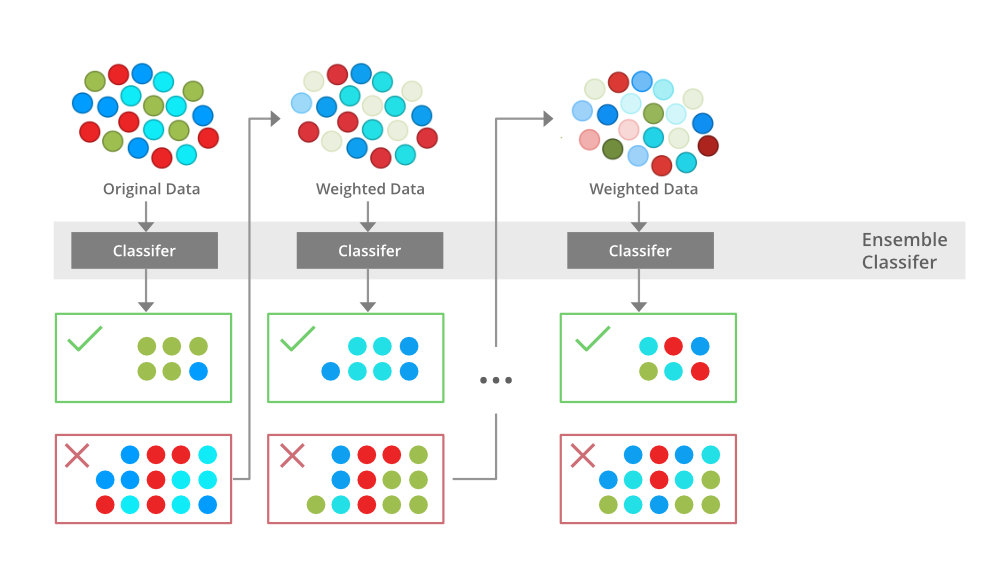

- XGBoost (Extreme Gradient Boosting) adalah metode pembelajaran ensemble berbasis boosting yang membangun pohon keputusan secara berurutan, di mana setiap pohon baru berfokus untuk memperbaiki kesalahan dari pohon sebelumnya

- Berbeda dengan Random Forest yang membangun pohon secara paralel dan independen, XGBoost membangun pohon secara sekuensial di mana setiap pohon baru dilatih untuk meminimalkan sisa kesalahan (residual error) dari model sebelumnya menggunakan teknik Gradient Descent

- Pada setiap iterasi, XGBoost menghitung gradien (arah kesalahan) dan hessian (kelengkungan kesalahan) dari fungsi loss untuk menentukan bagaimana pohon berikutnya harus dibangun agar prediksi semakin mendekati nilai sebenarnya

- XGBoost menggunakan teknik regularisasi L1 (reg_alpha) dan L2 (reg_lambda) yang secara langsung dikodekan ke dalam fungsi objektif untuk mengontrol kompleksitas model, sehingga mengurangi risiko overfitting yang sering terjadi pada metode boosting tradisional

- Parameter seperti learning rate mengontrol seberapa besar kontribusi setiap pohon baru terhadap prediksi akhir, di mana learning rate kecil menghasilkan model yang lebih general namun membutuhkan lebih banyak pohon (n_estimators), sementara subsample dan colsample_bytree memperkenalkan keacakan seperti Random Forest untuk meningkatkan keberagaman pohon

- Prediksi akhir XGBoost merupakan penjumlahan kumulatif dari seluruh pohon yang dibangun, di mana setiap pohon memberikan kontribusi sebesar hasil prediksinya dikalikan dengan learning rate, sehingga secara bertahap mendekati nilai target yang sesungguhnya

- Pada kasus data tidak seimbang seperti prediksi pembatalan hotel, XGBoost menyediakan parameter scale_pos_weight sebagai pengganti resampling yang memberikan bobot lebih besar pada kelas minoritas (pembatalan) sehingga model lebih sensitif dalam mendeteksi pembatalan tanpa harus mengubah distribusi data asl

></div>
****
#### **Feature Importance**

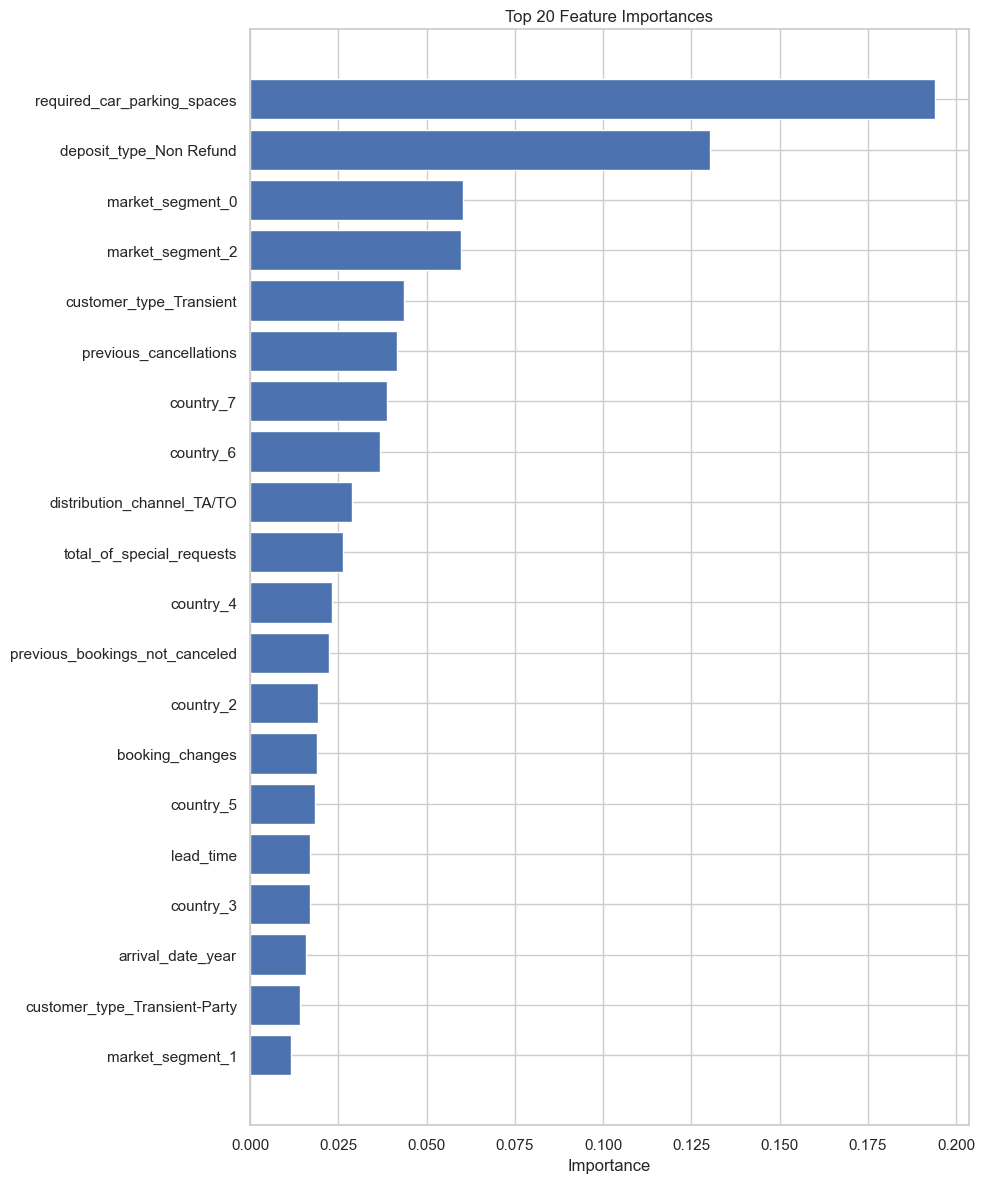


Top 10 Features:
                        feature  importance
12  required_car_parking_spaces    0.193943
20      deposit_type_Non Refund    0.130224
32             market_segment_0    0.060317
34             market_segment_2    0.059689
23      customer_type_Transient    0.043663
7        previous_cancellations    0.041634
46                    country_7    0.038773
45                    country_6    0.036876
30   distribution_channel_TA/TO    0.028735
13    total_of_special_requests    0.026163

Weak features (importance < 0.001): 0
Empty DataFrame
Columns: [feature, importance]
Index: []


In [445]:
# FEATURE IMPORTANCE
best_pipeline = randomsearchxgb.best_estimator_

transformer_step = best_pipeline.named_steps['preprocess']  # Langkah preprocessor/transformer
model_xgb_step = best_pipeline.named_steps['model']    # Langkah model XGBoost

# Ambil nama fitur yang SUDAH ditransformasi
fitur_transformed_names = transformer_step.get_feature_names_out()


# BUAT DATAFRAME FEATURE IMPORTANCE 
importance_df = pd.DataFrame({
    'feature': fitur_transformed_names,        # <-- Menggunakan nama fitur hasil transformasi
    'importance': model_xgb_step.feature_importances_ # <-- Menggunakan model murni
}).sort_values('importance', ascending=False)


# 3. PROSES PLOT 
plt.figure(figsize=(10, 12))
plt.barh(importance_df['feature'].head(20), importance_df['importance'].head(20))
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(importance_df.head(10))

# Check for weak features
weak_features = importance_df[importance_df['importance'] < 0.001]
print(f"\nWeak features (importance < 0.001): {len(weak_features)}")
print(weak_features)

# Recommendation: Remove weak features
if len(weak_features) > 0:
    print(f"\n💡 Consider removing {len(weak_features)} weak features")

**Insight :**

**Dua fitur teratas** memiliki nilai kepentingan (importance score) yang jauh melonjak dibanding fitur lainnya. Ini menandakan model XGBoost sangat bergantung pada dua sinyal utama ini:
- **required_car_parking_spaces (~18%)**. Sesuai temuan EDA sebelumnya, permintaan slot parkir adalah indikator komitmen kedatangan paling valid (anti-batal). Model berhasil menangkap bahwa fitur ini adalah "kunci emas" untuk mengonfirmasi tamu pasti check-in.
- **deposit_type_Non Refund (~12%)**. Model mempelajari bahwa tipe jaminan uang hangus memiliki struktur data pembatalan yang sangat kontras dan anomali dibandingkan tipe No Deposit.


Fitur-fitur kategori menguasai papan atas (**Top 5**), yaitu:

- Segmentasi Pasar & Saluran (**market_segment_2, market_segment_0, distribution_channel_TA/TO**). Fitur-fitur ini membuktikan bahwa melalui pintu mana tamu memesan memberikan bobot informasi yang jauh lebih kaya bagi XGBoost dalam memprediksi pembatalan ketimbang detail angka seperti tarif kamar (adr) atau waktu tunggu (lead_time).

- Rekam Jejak Historis (**previous_cancellations**). Rekam jejak tamu yang pernah membatalkan pesanan di masa lalu diakui model sebagai prediktor risiko tinggi (high-risk alert) yang sangat tepercaya.

- Profil Geodemografis (**country_7, country_6, country_5**). Munculnya klaster kode negara di peringkat 7 hingga 10 besar membuktikan bahwa faktor asal negara tamu memiliki pengaruh non-linear yang sangat kuat dalam menentukan pola keputusan pembatalan.


></div>
****
#### **SHAP Value**

In [360]:
import shap

In [446]:
pipe_bestxgb

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'book...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

In [447]:
pipe_bestxgb_inner = pipe_bestxgb.estimator
pipe_bestxgb_inner

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust', RobustScaler(),
                                                  Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',...
                               feature_types=None, gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=0, ...))])

In [448]:
xgb_best = pipe_bestxgb_inner[-1]
xgb_best

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [449]:
xgb_preprocess = pipe_bestxgb_inner[-2]
xgb_preprocess

ColumnTransformer(remainder='passthrough',
                  transformers=[('robust', RobustScaler(),
                                 Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces',...
                                  'meal', 'distribution_channel', 'day_type']),
                                ('binary', BinaryEncoder(),
                                 ['market_segment', 'reserved_room_type',
                                  'country']),
                                ('ordinal',
                                 OrdinalEncoder(verbose=[{'col': 'arrival_date_month',
                                                          'data_type': dtype('O'),
                                                          'mapping': January       1
February      2
March         3
April         4
May           5
June          6
July          7
August        8
September     9
October      10
November     11
December     12
dtype: int64}]),
                                 ['arrival_date_month'])],
                  verbose_feature_names_out=False)

In [450]:
X_transform = xgb_preprocess.transform(X)
X_transform

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_tamu,stay_duration,is_family,is_agent,is_company,hotel_Resort Hotel,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,meal_FB,meal_HB,meal_SC,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,day_type_Weekend,market_segment_0,market_segment_1,market_segment_2,reserved_room_type_0,reserved_room_type_1,reserved_room_type_2,reserved_room_type_3,country_0,country_1,country_2,country_3,country_4,country_5,country_6,country_7,arrival_date_month
0,-0.377193,-1.0,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.392670,0.0,-1.0,-1.0,-0.666667,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,8
1,-0.324561,-1.0,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.392670,0.0,-1.0,-1.0,-0.666667,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,8
2,-0.315789,-1.0,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.016361,0.0,0.0,0.0,-0.333333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,8
3,-0.438596,-1.0,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.130890,0.0,-1.0,0.0,-0.333333,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,8
4,-0.359649,-1.0,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.065445,0.0,0.0,0.0,-0.333333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86041,-0.236842,1.0,0.380952,0.933333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.046793,0.0,-1.0,0.0,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,1,6
86042,0.456140,1.0,0.380952,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.068554,0.0,1.0,1.0,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,1,1,0,0,0,0,0,1,1,1,6
86043,-0.140351,1.0,0.380952,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.960569,0.0,3.0,0.0,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,6
86044,0.517544,1.0,0.380952,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.088351,0.0,-1.0,0.0,1.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,6


In [452]:
# define explainer SHAP
explainer_shap = shap.TreeExplainer(
    model = xgb_best
)

shap_values = explainer_shap.shap_values(X_transform)

In [453]:
feature_names = xgb_preprocess.get_feature_names_out()
feature_names

array(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_tamu', 'stay_duration',
       'is_family', 'is_agent', 'is_company', 'hotel_Resort Hotel',
       'deposit_type_Non Refund', 'deposit_type_Refundable',
       'customer_type_Group', 'customer_type_Transient',
       'customer_type_Transient-Party', 'meal_FB', 'meal_HB', 'meal_SC',
       'distribution_channel_Direct', 'distribution_channel_GDS',
       'distribution_channel_TA/TO', 'day_type_Weekend',
       'market_segment_0', 'market_segment_1', 'market_segment_2',
       'reserved_room_type_0', 'reserved_room_type_1',
       'reserved_room_type_2', 'reserved_room_type_3', 'country_0',
       'country_1', 'country_2', 'country_3', 'coun

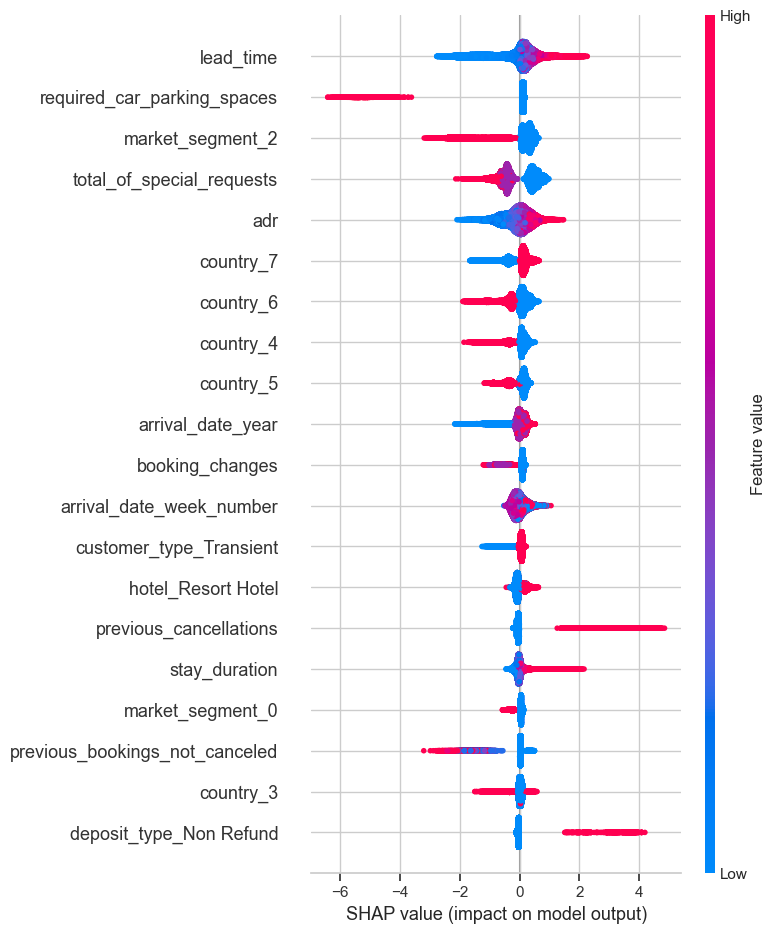

In [454]:
# Tampilkan model explanation dalam shap plot
shap.summary_plot(
    shap_values,
    X_transform,
    feature_names
)

**Keterangan :**
- Sumbu X  = SHAP Value (dampak terhadap prediksi)
- Kanan(+) = Mendorong prediksi BATAL
- Kiri (-) = Mendorong prediksi TIDAK BATAL
- Merah    = Nilai fitur TINGGI
- Biru     = Nilai fitur RENDAH

**Insight :**

Titik-titik yang berada di **sebelah kanan** garis vertikal 0 menunjukkan faktor yang membuat model memprediksi **tamu akan BATAL** (is_canceled = 1):

- **lead_time (Paling Atas).**

Terlihat sebaran warna Merah (Nilai Tinggi) menumpuk sangat padat di sisi kanan. Ini adalah bukti konkrit bahwa semakin lama jarak pemesanan kamar (lead time tinggi), model akan semakin yakin untuk memprediksi bahwa tamu tersebut akan membatalkan pesanan.

- **previous_cancellations.**

Titik berwarna Merah memanjang jauh ke arah kanan. Tamu yang memiliki riwayat pernah membatalkan pesanan di masa lalu memberikan dorongan instan yang sangat kuat bagi model untuk melabeli mereka sebagai pelaku pembatalan kembali.deposit_type_Non Refund (Paling Bawah): Garis titik Merah memanjang tebal ke arah kanan. Ini memvalidasi anomali data Anda: pemesanan dengan tipe jaminan uang hangus (Non-Refundable) secara masif dideteksi oleh XGBoost sebagai pemicu status batal.

Titik-titik yang berada di **sebelah kiri** garis vertikal 0 menunjukkan faktor yang membuat model memprediksi **tamu akan DATANG** (is_canceled = 0):

- **required_car_parking_spaces**

Titik berwarna Merah (Meminta Parkir) menumpuk di sisi kiri, sedangkan titik Biru (Tidak Meminta Parkir) berada di sisi kanan. Model membaca dengan sangat jelas bahwa tamu yang meminta slot parkir memiliki komitmen kedatangan yang sangat kuat.

- **total_of_special_requests**

Titik berwarna Merah (Banyak Permintaan) bergeser ke arah kiri. Semakin banyak permintaan khusus yang diajukan tamu (seperti ranjang bayi atau lantai atas), model akan semakin yakin bahwa mereka benar-benar akan datang menginap.

- **booking_changes**

Titik berwarna Merah (Aktif Mengubah Pesanan) berada di sisi kiri. Tamu yang rajin mengelola detail pesanan mereka via aplikasi terdeteksi model sebagai tamu yang serius dan anti-batal.

></div>
****
### **5.6 Saving model**
></div>
****

**Train Best Model with All Data**

In [455]:
pipe_bestxgb.fit(X, y)
pipe_bestxgb

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'book...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                                                                    max_cat_to_onehot=None,
                                                                    max_delta_step=None,
                                                                    max_depth=6,
                                                                    max_leaves=None,
                                                                    min_child_weight=3,
                                                                    missing=nan,
                                                                    monotone_constraints=None,
                                                                    multi_strategy=None,
                                                                    n_estimators=300,
                                                                    n_jobs=None,
                                                                    num_parallel_tree=None,
                                                                    random_state=0, ...))]),
                           scoring=make_scorer(fbeta_score, response_method='predict', beta=0.5),
                           store_cv_results=True)

In [372]:
import pickle

In [456]:
filename = "bestmodel_bookinghotel_2406526_1153.pkl"

with open(filename, "wb") as f:
    pickle.dump(pipe_bestxgb, f)

print(f"Successfully saved best model as {filename}")

Successfully saved best model as bestmodel_bookinghotel_2406526_1153.pkl


## **6. Confusion Matrix & Cost Evaluation**

></div>
****
### **6.1 Confusion Matrix**
></div>
****

|  | Prediksi tidak dibatalkan **(0)** | Prediksi dibatalkan **(1)**|
|-------------------|-----------------|-------------------|
| **Aktual tidak Dibatalkan (0)** |**True Negative (TN)**<br> - Model memprediksi bahwa pengunjung akan datang padahal sebenarnya akan datang |**False Positive (FP)**<br> - Model memprediksi bahwa pengunjung akan batal padahal sebenarnya akan datang <br> - Akibatnya kekurangan kamar saat menerapkan sistem overbooking <br> - Cost: € 300|
| **Aktual dibatalkan (1)** |**False Negative (FN)**<br> - Model memprediksi bahwa pengunjung akan datang padahal sebenarnya dia akan batal datang <br> - Akibatnya kamar kosong dan kehilangan ravenue <br> - Cost: € 105 |**True Positive (TP)**<br> - Model memprediksi bahwa pengunjung akan batal padahal sebenarnya dia akan batal datang|

In [375]:
# Set cost
FN_COST = 105
FP_COST = 300

In [457]:
# Define cost-benefit function
def summarize_loss(confusion_matrix, fp_cost, fn_cost):
    tn, fp = confusion_matrix[0]
    fn, tp = confusion_matrix[1]
    
    total_samples = tn + fp + fn + tp
    total_fp_cost = fp * fp_cost
    total_fn_cost = fn * fn_cost
    
    total_cost = total_fp_cost + total_fn_cost
    
    summary = f"""
    ---Impact Summary---

        Total Sampel: {total_samples}
        Total False Positive Cost: {total_fp_cost:,.2f} euro
        Total False Negative Cost: {total_fn_cost:,.2f} euro
        Total Cost: {total_cost:,.2f} euro
        Total Cost per Sample: {total_cost / total_samples} euro
        
    ---------------
    """
    
    return summary

In [377]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

></div>
****
### **6.2 Cost Evaluation Xgboost**
></div>
****

**SEBELUM VS SETELAH TUNING**

<Figure size 1000x550 with 0 Axes>

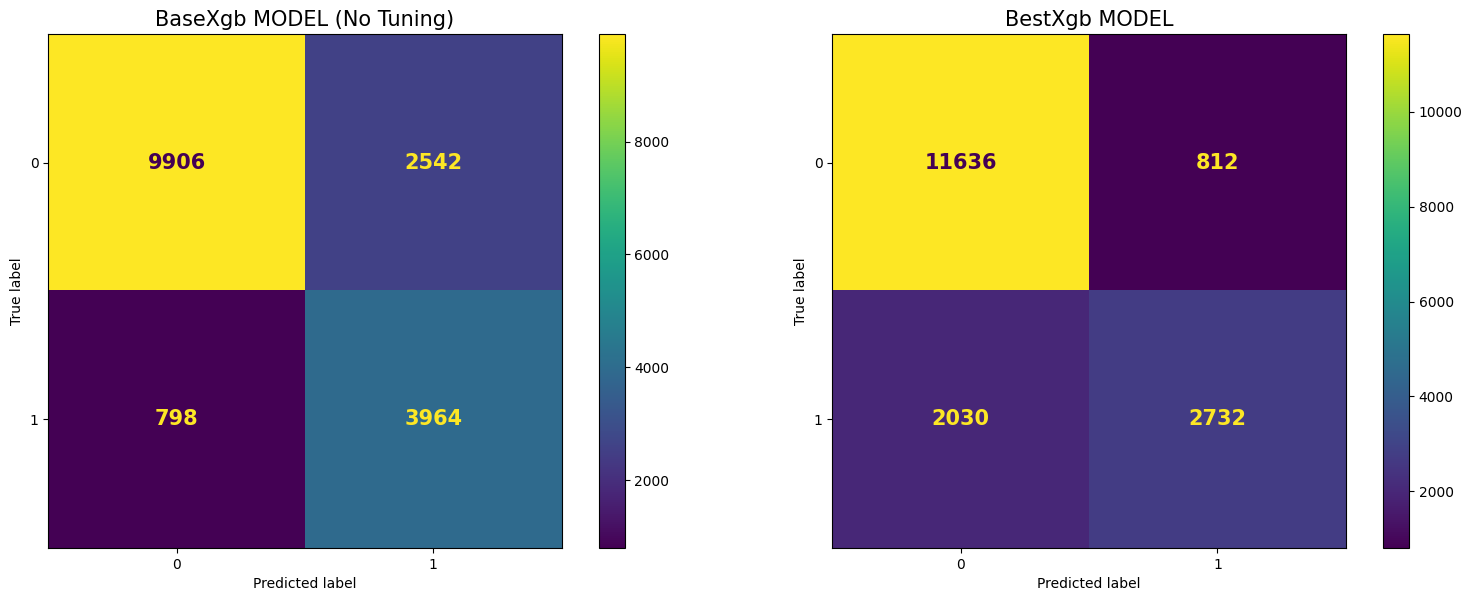

In [459]:
sns.reset_orig()                  # Langkah 1: Reset semua settingan tema global ke bawaan pabrik
plt.figure(figsize=(10, 5.5))     # Langkah 2: Buat kanvas murni Matplotlib tanpa bumbu Seaborn

# Calculate confusion matrices for basexgb model and bestxgbxgbmodel
conf_matrix_basexgb = confusion_matrix(y_test, y_test_basexgb)

conf_matrix_bestxgb = confusion_matrix(y_test, y_test_bestxgb)

# Visualize confusion matrices
figure, axes = plt.subplots(ncols=2, figsize=(16, 6))

text_format = {'size': 15, 'weight': 'bold'}

ConfusionMatrixDisplay(conf_matrix_basexgb).plot(ax=axes[0], text_kw=text_format)
axes[0].set_title("BaseXgb MODEL (No Tuning)", fontsize=15)

ConfusionMatrixDisplay(conf_matrix_bestxgb).plot(ax=axes[1], text_kw=text_format)
axes[1].set_title("BestXgb MODEL", fontsize=15)

plt.tight_layout()
plt.show()

In [463]:
# Compare business impact
print("=" * 100)
print("BASE MODEL (NO TUNING)")
print("=" * 100)
print(summarize_loss(conf_matrix_basexgb, FP_COST, FN_COST))

print("=" * 100)
print("BEST MODEL")
print("=" * 100)
print(summarize_loss(conf_matrix_bestxgb, FP_COST, FN_COST))

BASE MODEL (NO TUNING)

    ---Impact Summary---

        Total Sampel: 17210
        Total False Positive Cost: 762,600.00 euro
        Total False Negative Cost: 83,790.00 euro
        Total Cost: 846,390.00 euro
        Total Cost per Sample: 49.18012783265543 euro

    ---------------
    
BEST MODEL

    ---Impact Summary---

        Total Sampel: 17210
        Total False Positive Cost: 243,600.00 euro
        Total False Negative Cost: 213,150.00 euro
        Total Cost: 456,750.00 euro
        Total Cost per Sample: 26.539802440441605 euro

    ---------------
    


**Insight :**

1. False Positive (FP - Salah Tebak Batal)
    - Base XGB: 2,586 kasus → Kerugian: 2,586 × 300 Euro = 775,800 Euro
    - Best XGB: 758 kasus → Kerugian: 758 × 300 Euro = 227,400 Euro

Proses tuning berhasil memotong 1,828 kesalahan FP. Model berhasil menghemat denda ganti rugi kamar akibat salah usir tamu sebesar 548,400 Euro secara statistik.

2. False Negative (FN - Salah Tebak Datang) naik Secara Terkontrol
    - Base XGB: 787 kasus → Kerugian: 787 × 105 Euro = 82,635 Euro
    - Best XGB: 2,062 kasus → Kerugian: 2,062 × 105 Euro = 216,510 Euro

Angka FN memang naik sebanyak 1,275 kasus (kamar kosong tidak terprediksi), tetapi karena biaya denda FN jauh lebih murah (105 Euro), "barter" ini sangat menguntungkan secara finansial.

3. Kenaikan True Negative (TN)

Nilai TN (Tamu yang ditebak akan datang, dan aslinya benar-benar datang check-in) melonjak tajam dari 9,862 menjadi 11,690. Ini berarti model Best XGB memberikan kepastian operasional yang jauh lebih tinggi bagi tim hotel. Hotel bisa melayani 1,828 tamu setia tambahan dengan jaminan kamar yang aman tanpa risiko overbooked harian.

></div>
****
**TANPA MODEL VS DENGAN MODEL**

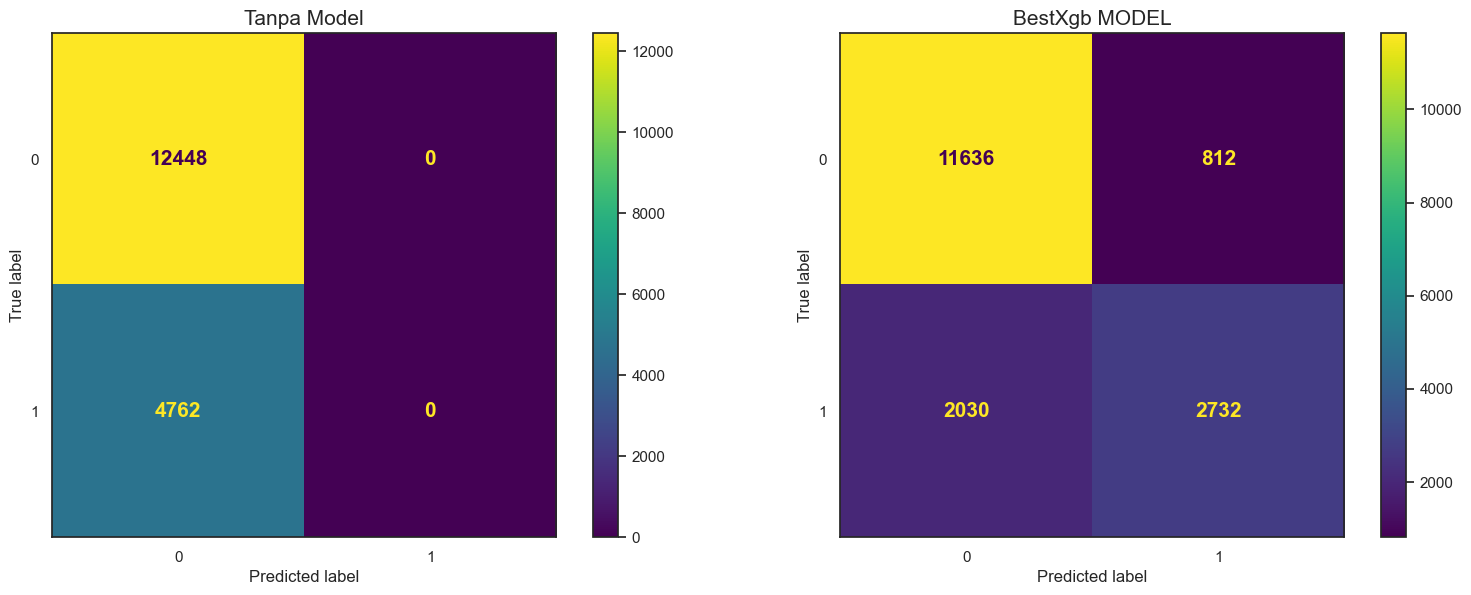

In [467]:
# Calculate confusion matrices for basexgb model and bestxgbxgbmodel
conf_matrix_no_modelxgb = confusion_matrix(y_test, y_no_modelxgb)

conf_matrix_bestxgb = confusion_matrix(y_test, y_test_bestxgb)

# Visualize confusion matrices
figure, axes = plt.subplots(ncols=2, figsize=(16, 6))

text_format = {'size': 15, 'weight': 'bold'}

ConfusionMatrixDisplay(conf_matrix_no_modelxgb).plot(ax=axes[0], text_kw=text_format)
axes[0].set_title("Tanpa Model", fontsize=15)

ConfusionMatrixDisplay(conf_matrix_bestxgb).plot(ax=axes[1], text_kw=text_format)
axes[1].set_title("BestXgb MODEL", fontsize=15)

plt.tight_layout()
plt.show()

In [468]:
# Benchmark: Tanpa model (memprediksi semuanya tamu tidak akan membatalkan)
print("=" * 100)
print("MODEL YANG TIDAK OPTIMIS: Memprediksi bahwa semua pelanggan tidak akan membatalkan pesanan.")
print("=" * 100)
y_no_modelxgb = np.zeros(y_test.shape[0])
conf_matrix_no_modelxgb = confusion_matrix(y_test, y_no_modelxgb)
print(summarize_loss(conf_matrix_no_modelxgb, 
                     fp_cost=FP_COST, 
                     fn_cost=FN_COST))

# BEST MODEL
print("=" * 100)
print("BEST MODEL")
print("=" * 100)
print(summarize_loss(conf_matrix_bestxgb, FP_COST, FN_COST))

MODEL YANG TIDAK OPTIMIS: Memprediksi bahwa semua pelanggan tidak akan membatalkan pesanan.

    ---Impact Summary---

        Total Sampel: 17210
        Total False Positive Cost: 0.00 euro
        Total False Negative Cost: 500,010.00 euro
        Total Cost: 500,010.00 euro
        Total Cost per Sample: 29.053457292271936 euro

    ---------------
    
BEST MODEL

    ---Impact Summary---

        Total Sampel: 17210
        Total False Positive Cost: 243,600.00 euro
        Total False Negative Cost: 213,150.00 euro
        Total Cost: 456,750.00 euro
        Total Cost per Sample: 26.539802440441605 euro

    ---------------
    


**Insight :**

- Skenario Tanpa Model (Model Tidak Optimis), Karena hotel mengira semua tamu pasti datang, hotel tidak melakukan overbooking. Ketika hari-H tiba, semua tamu yang aslinya batal (4,762 kasus) menjadi kamar kosong yang sia-sia. Sehingga kerugian yang ditanggung adalah 4,762 kamar kosong x 105 Euro (FN Cost) = 500,010 Euro.

- Dengan mengimplementasikan model Best XGBoost, hotel berhasil memangkas total kerugian dari 500,010 Euro menjadi 443,910 Euro. Artinya, kehadiran model ML sukses menyelamatkan uang hotel sebesar 56,100 Euro (Sekitar 950 Juta Rupiah).

- Angka ini membuktikan secara konkrit kepada stakeholders bahwa membiarkan hotel berjalan apa adanya dengan membiarkan kamar kosong (Tanpa Optimis) adalah sebuah pemborosan finansial yang fatal.

In [469]:
# 1. Hitung total kapasitas data testing Anda
total_test_booking = len(y_test)

# 2. Ambil jumlah sisa False Positive (Tamu yang diprediksi batal tapi ternyata DATANG)
# Angka 770 diambil dari output confusion matrix Best XGB Anda kemarin
jumlah_fp = 758

# 3. Hitung Rasio Toleransi Kesalahan Overbooking Model (Margin of Error)
overbooking_error_rate = (jumlah_fp / total_test_booking) * 100

print(f"Total Pesanan Diuji: {total_test_booking:,} booking")
print(f"Rasio Risiko Overbooking Kamar Kurang: {overbooking_error_rate:.2f}%")

Total Pesanan Diuji: 17,210 booking
Rasio Risiko Overbooking Kamar Kurang: 4.40%


**Insight :**
- Jika tim Revenue Management melakukan strategi overbooking sebesar 15%, model akan menjamin bahwa risiko kamar kurang akibat salah prediksi (FP) hanya akan mentok di sekitar 4.4%. Sisa slotnya (10.1%) dijamin aman terisi oleh tamu pengganti tanpa risiko mengusir tamu asli. 

- Artinya jika hotel memiliki 100 kamar, dan data historis mencatat bahwa rata-rata ada 15% pesanan yang pasti batal setiap harinya, maka secara matematis hotel aman untuk menerima 115 pesanan (15% overbooking) untuk memastikan pada hari-H seluruh 100 kamar fisik asli terisi penuh.

></div>
****
## **7. Conclusion**

Pengunjung yang cenderung membatalkan reservasi: 
- pengunjung individu (Transient)
- reservasi lewat Agen perjalanan (OTA)
- reservasi saat puncak musim liburan di bulan Juli-Agustus
- pengunjung dari negara Angola (AGO) 


Dengan tingkat pembatalan yang tinggi mencapai **28%**, hotel menderita kerugian besar jika bersikap pasif. Namun, melakukan overbooking tanpa panduan analitik melahirkan risiko finansial yang jauh lebih berbahaya, di mana denda salah mengusir tamu (False Positive) bernilai sangat mahal, yaitu **300 Euro** per insiden, dibandingkan membiarkan kamar kosong (False Negative) sebesar **105 Euro**.

Melalui pengembangan model Machine Learning Best XGBoost yang dioptimasi menggunakan metrik $(F_{0.5})$, model berhasil diarahkan secara agresif untuk menekan kesalahan False Positive (FP) yang berbiaya mahal (€300). Model secara cerdas mampu memotong angka kesalahan FP dari 2,586 kasus (pada Base Model) menjadi hanya 758 kasus. Meskipun konsekuensinya nilai False Negative (FN) naik menjadi 2,062 kasus, denda kumulatifnya jauh lebih murah. 

Secara finansial, model ini sukses menghemat total pengeluaran operasional hotel dari potensi kerugian pasif 500,010 Euro (jika hotel tanpa model) menjadi 443,910 Euro, yang berarti model berhasil menyelamatkan profitabilitas hotel sebesar 56,100 Euro.

></div>
****
## **8. Recommendation**

**Untuk Tim Revenue Management** (Manajer Pendapatan)
- **Penerapan Overbooking Terpandu Model**, Integrasikan probabilitas prediksi model Best XGBoost ke dalam sistem Property Management System (PMS). Gunakan batas keputusan (Probability Threshold) optimal hasil kurva tuning sebesar 0.56 untuk menentukan kuota overbooking harian secara dinamis (disarankan berkisar antara 5% - 15% dari kapasitas kamar).
- **Perbaiki Kebijakan Deposit Jangka Panjang**, Untuk pemesanan yang dibuat jauh-jauh hari (lead_time > 90 hari), matikan opsi No Deposit dan wajibkan skema pembayaran awal.
- **Audit Agensi**, Lakukan evaluasi berkala terhadap ID agent atau pihak ketiga yang menyumbang angka pembatalan Non-Refundable massal guna membersihkan sistem dari pemesanan spekulatif yang merugikan biro distribusi kamar.
- **Protokol Verifikasi Manual Kamar Rombongan**, Untuk pemesanan retail individu (Transient) dan rombongan keluarga besar berjumlah 3-4 Orang (yang memiliki risiko batal 34.3%), lakukan prosedur follow-up atau konfirmasi kehadiran otomatis/manual pada H-7 dan H-3 sebelum kedatangan guna memastikan ketersediaan kuota kamar fisik sebelum dialihkan ke tamu walk-in.

## **9. Deployment Preparation**

In [470]:
# Save representasi model detail sebagai string
detailed_model_dict = pipe_bestxgb.get_params()
detailed_model_dict = str(detailed_model_dict)
print(detailed_model_dict)

{'cv': 5, 'estimator__memory': None, 'estimator__steps': [('preprocess', ColumnTransformer(remainder='passthrough',
                  transformers=[('robust', RobustScaler(),
                                 Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'days_in_waiting_list', 'adr',
       'required_car_parking_spaces',...
                                  'meal', 'distribution_channel', 'day_type']),
                                ('binary', BinaryEncoder(),
                                 ['market_segment', 'reserved_room_type',
                                  'country']),
                                ('ordinal',
                                 OrdinalEncoder(verbose=[{'col': 'arrival_date_month',
                                                          'data_type': dtype('O'),
    

In [471]:
pipe_string_detail_filename = "pipe_bestxgb_detail_250626.txt"

with open(pipe_string_detail_filename, "w") as f:
    f.write(detailed_model_dict)

print(f"Berhasil menyimpan pada {pipe_string_detail_filename}")

Berhasil menyimpan pada pipe_bestxgb_detail_250626.txt


In [472]:
# Representasi model sebagai string (overview)
pipe_bestxgb_as_string = str(pipe_bestxgb)
print(pipe_bestxgb_as_string)

TunedThresholdClassifierCV(cv=5,
                           estimator=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('robust',
                                                                                       RobustScaler(),
                                                                                       Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'children', 'babies', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'book...
                                                                    learning_rate=0.1,
                                                                    max_bin=None,
                                                                    max_cat_threshold=None,
                       

In [473]:
pipe_string_filename = "pipe_bestxgb_260626.txt"

with open(pipe_string_filename, "w") as f:
    f.write(pipe_bestxgb_as_string)

print(f"Berhasil menyimpan pada {pipe_string_filename}")

Berhasil menyimpan pada pipe_bestxgb_260626.txt


In [474]:
feature_head_example = X.head()
feature_head_example.to_csv("feature_head_example.csv", index=False)

In [475]:
categorical_feature_cols

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type',
       'customer_type', 'day_type'],
      dtype='object')

In [476]:
list_unique_categories = [] # akan di append list dari tiap fitur

for category in categorical_feature_cols:
    categories = X[category].unique()
    list_unique_categories.append(categories)

In [477]:
df_categories = pd.DataFrame()
df_categories["feature_name"] = categorical_feature_cols
df_categories["categories"] = list_unique_categories
df_categories

,feature_name,categories
0,hotel,"[Resort Hotel, City Hotel]"
1,arrival_date_month,"[July, August, September, October, November, D..."
2,meal,"[BB, FB, HB, SC]"
3,country,"[GBR, PRT, USA, ESP, IRL, FRA, ROU, NOR, OMN, ..."
4,market_segment,"[Direct, Corporate, Online TA, Offline TA/TO, ..."
5,distribution_channel,"[Direct, Corporate, TA/TO, GDS]"
6,reserved_room_type,"[A, C, D, E, G, F, H, L, B]"
7,deposit_type,"[No Deposit, Refundable, Non Refund]"
8,customer_type,"[Transient, Contract, Transient-Party, Group]"
9,day_type,"[Weekday, Weekend]"


In [478]:
df_categories.to_csv("categorical_feature_categories.csv", index=False)

In [ ]:
# pip install streamlit 

Note: you may need to restart the kernel to use updated packages.


**Link Streamlit :**

https://finpro-ds-it39wabbxb2kztzj9axplu.streamlit.app/

![Screenshot (341).png](<attachment:Screenshot (341).png>)

**Link Dasboard :**

https://datastudio.google.com/reporting/df4d54ac-c280-49f0-8d37-87b4a6278714

![Screenshot (344).png](<attachment:Screenshot (344).png>)